# **Pronósticos basados en series de tiempo**

## Martín Naranjo - Sergio Aguilar - Edgar Orlando Ruiz
## Universidad Javeriana-Cali



## **1. Carga de paquetes**

In [ ]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error


Este documento presenta una breve introducción a la construcción de objetos de series de tiempo y al cálculo de pronósticos con modelos de suavización. Para el desarrollo de esta práctica se trabajará con la variable Ocupados, correspondiente al número de personas ocupadas, en miles, en las trece principales ciudades de Colombia. A partir de esta serie mensual, se buscará identificar su comportamiento histórico, evaluar diferentes alternativas de pronóstico y seleccionar el modelo que presente mejor desempeño fuera de muestra. De esta manera, la práctica permitirá comprender tanto la ejecución técnica del modelo en Python como la lógica estadística asociada a la preparación de la serie, la división entre datos de entrenamiento y prueba, la comparación de errores y la interpretación de las proyecciones obtenidas.

## **2. Carga de datos**

La primera etapa de la práctica consiste en cargar la base de datos que contiene la información mensual del mercado laboral para las trece principales ciudades de Colombia. Esta base incluye diferentes variables, como la tasa de desempleo, el número de ocupados, desocupados e inactivos. En el desarrollo de esta actividad se tomará como variable principal Ocupados, que representa el número de personas ocupadas, expresado en miles. La correcta lectura de los datos es un paso fundamental, porque de ella depende que la serie temporal quede organizada de manera adecuada para su posterior análisis, visualización, separación entre muestra de entrenamiento y prueba, estimación de modelos de suavización exponencial y construcción de pronósticos. Por esta razón, antes de avanzar con los modelos, se verificará que la información haya sido importada correctamente y que la columna correspondiente al tiempo sea reconocida como índice de fechas.

In [ ]:
data = pd.read_excel(
    "https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",
    index_col='mes',
    parse_dates=True
)

data.head().style.map(
    lambda x: "background-color: #fff2cc; font-weight: bold",
    subset=["Ocupados"]
)

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01 00:00:00,20.946380,6923.604000,1834.507000,4600.718000
2001-02-01 00:00:00,19.894213,7037.746000,1747.820000,4596.805000
2001-03-01 00:00:00,19.221565,6945.973000,1652.823000,4807.120000
2001-04-01 00:00:00,17.888575,6973.079000,1519.137000,4937.280000
2001-05-01 00:00:00,17.945654,6994.462000,1529.720000,4928.911000


En este caso, los datos fueron leídos como un data frame de pandas, lo que permite organizar la información en una estructura similar a una tabla. Además, la columna mes fue definida como índice de la base de datos y reconocida como una fecha. Esta decisión es importante porque facilita el análisis de la información como una serie de tiempo mensual. A partir de esta estructura, será posible graficar la evolución histórica de la variable Ocupados, separar la información en datos de entrenamiento y prueba, estimar diferentes modelos de suavización exponencial y construir pronósticos para los próximos meses. De esta manera, antes de iniciar la modelación, se verifica que la base esté organizada adecuadamente para el análisis temporal.

(222, 4)


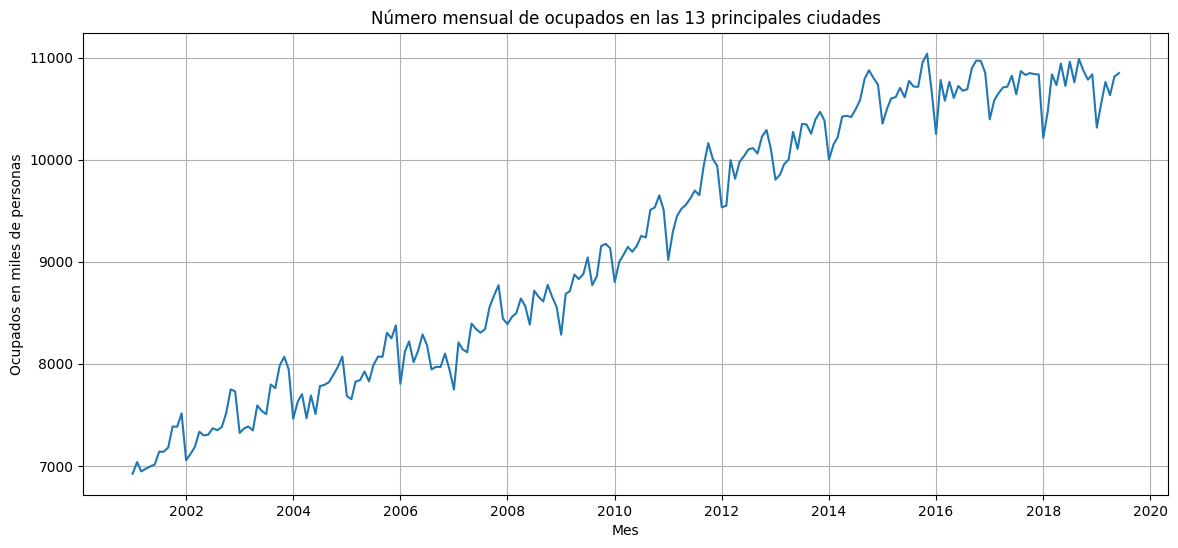

In [ ]:
# Imprimiendo el tamaño del dataframe
print(data.shape)

# Graficando la serie de ocupados
plt.figure(figsize=(14, 6))

plt.title("Número mensual de ocupados en las 13 principales ciudades")
plt.xlabel("Mes")
plt.ylabel("Ocupados en miles de personas")

plt.plot(data[["Ocupados"]])

plt.grid()
plt.show()

## **3. Pronosticando metodos de suavización**

Antes de construir los modelos de pronóstico, es necesario definir una estrategia para evaluar su desempeño. En esta práctica se utilizarán métodos de suavización exponencial aplicados a la serie mensual de Ocupados, con el propósito de estimar su comportamiento futuro a partir de la información histórica disponible. Para evitar evaluar los modelos únicamente sobre los mismos datos con los que fueron ajustados, se reservará una parte final de la serie como muestra de prueba. Esta separación permitirá comparar los pronósticos generados por cada modelo frente a valores reales que no fueron utilizados durante el entrenamiento. De esta manera, la selección del modelo no dependerá solo de qué tan bien se ajusta al pasado, sino de su capacidad para anticipar datos fuera de muestra, que es justamente lo que interesa en un ejercicio de pronóstico.

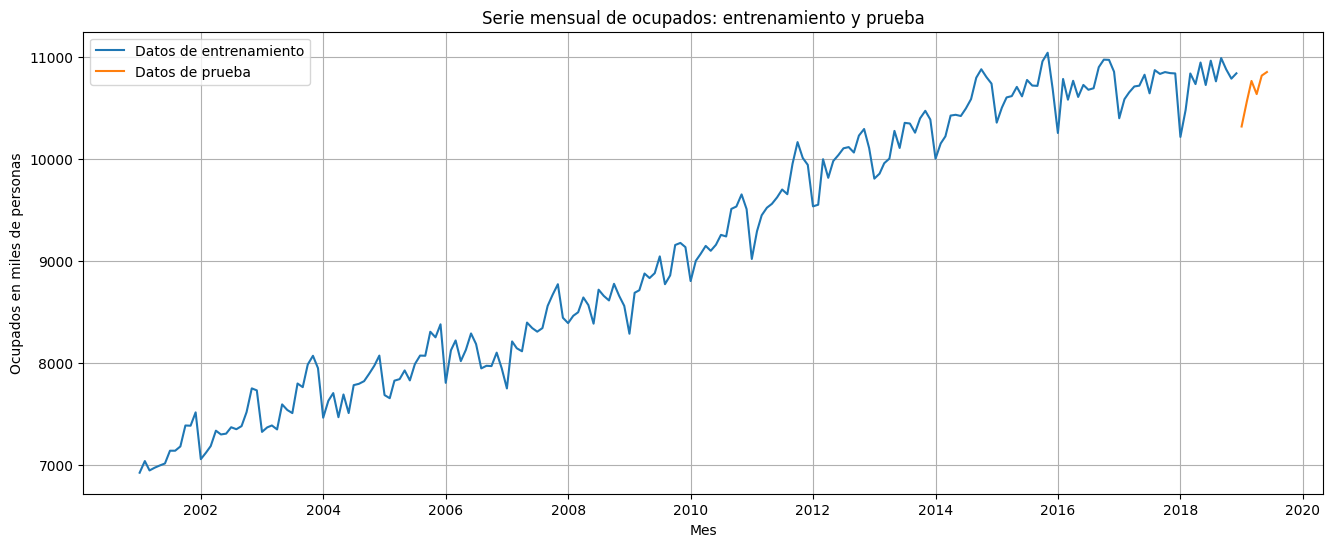

In [ ]:
# Separación de la serie en datos de entrenamiento y datos de prueba

# Se reservan los últimos 6 meses como muestra de prueba,
# porque el objetivo final de la actividad es pronosticar 6 meses hacia adelante.
test_len = 6

train_ocupados = data[["Ocupados"]][:-test_len]
test_ocupados = data[["Ocupados"]][-test_len:]

# Gráfico de la serie separada en entrenamiento y prueba
fig = plt.figure(figsize=(16, 6))

plt.plot(train_ocupados, label="Datos de entrenamiento")
plt.plot(test_ocupados, label="Datos de prueba")

plt.title("Serie mensual de ocupados: entrenamiento y prueba")
plt.xlabel("Mes")
plt.ylabel("Ocupados en miles de personas")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
train_ocupados

,Ocupados
mes,
2001-01-01,6923.604
2001-02-01,7037.746
2001-03-01,6945.973
2001-04-01,6973.079
2001-05-01,6994.462
...,...
2018-08-01,10756.782
2018-09-01,10984.928
2018-10-01,10874.338


In [ ]:
test_ocupados

,Ocupados
mes,
2019-01-01,10314.438
2019-02-01,10557.917
2019-03-01,10760.776
2019-04-01,10632.028
2019-05-01,10813.000
2019-06-01,10848.000


### **3.1 Suavizacion Exponencial Simple**

La suavización exponencial simple es el primer método de pronóstico que se aplicará sobre la serie Ocupados. Este modelo utiliza principalmente el nivel de la serie y asigna mayor peso a las observaciones más recientes, bajo la idea de que los datos cercanos en el tiempo suelen aportar más información para estimar el comportamiento futuro. Sin embargo, este método no incorpora explícitamente componentes de tendencia ni estacionalidad, por lo que funciona mejor cuando la serie se mantiene relativamente estable alrededor de un nivel promedio. En esta práctica se utilizará como modelo base, con el propósito de evaluar qué tan bien logra pronosticar los últimos 6 meses reservados como muestra de prueba y compararlo posteriormente con modelos más completos, como Holt y Holt-Winters.

In [ ]:
# Build model.
ets_model = ETSModel(endog=train_ocupados["Ocupados"], error="add") #,trend="add",seasonal="mul" )
ets_result = ets_model.fit()

point_forecast = ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05) #.iloc[:,0]
limits = ci.predicted_mean


preds = pd.concat([limits, conf_forecast], axis = 1)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

            Point_forecast      lower_95      upper_95
2019-01-01    10830.738569  10476.461345  11185.015792
2019-02-01    10830.738569  10411.310139  11250.166999
2019-03-01    10830.738569  10354.999076  11306.478061
2019-04-01    10830.738569  10304.681612  11356.795526
2019-05-01    10830.738569  10258.773728  11402.703409
2019-06-01    10830.738569  10216.286263  11445.190874


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


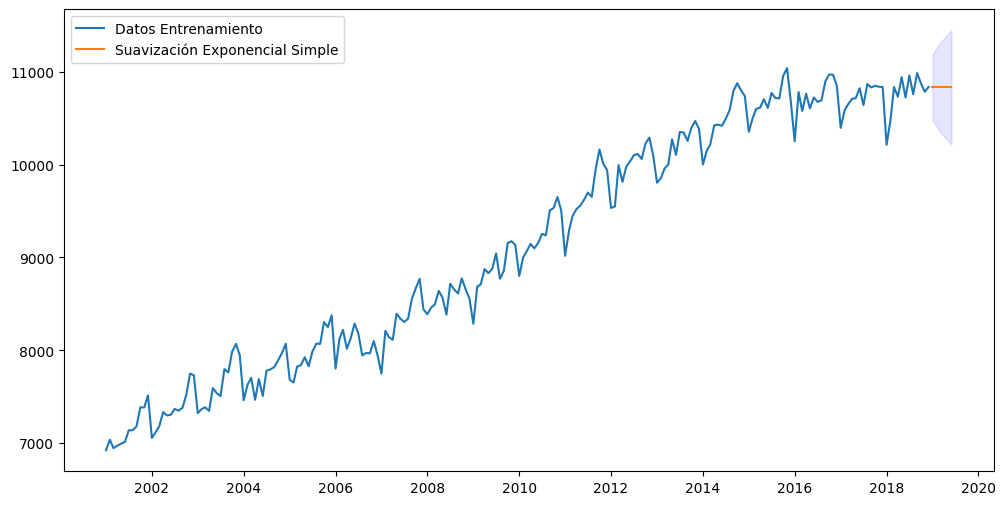

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos Entrenamiento")
plt.plot(preds['Point_forecast'], label="Suavización Exponencial Simple")
plt.fill_between(preds.index, preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En este caso, el α estimado es 0.6337. Este valor indica que el modelo de suavización exponencial simple asigna un peso relativamente importante a las observaciones más recientes de la serie **Ocupados** para actualizar el nivel de la serie. Por su parte, el RMSE en la muestra de evaluación es 253.64, calculado al comparar los pronósticos generados para los 6 meses de prueba frente a los valores reales observados. Este resultado constituye una primera medida del desempeño del modelo y servirá como referencia para compararlo con modelos posteriores que incorporen tendencia y/o estacionalidad. Este resultado constituye una primera referencia de desempeño, pero aún no permite seleccionar el mejor modelo, dado que todavía no se ha comparado con alternativas que incorporen tendencia o estacionalidad.

In [ ]:
alpha = ets_result.alpha
print(f"Alpha estimado: {alpha:.4f}")

Alpha estimado: 0.6337


In [ ]:
rmse = np.sqrt(mean_squared_error(test_ocupados, point_forecast))
print(f"RMSE: {rmse:.2f}")

RMSE: 253.64


### **3.2 Suavizacion Exponencial Lineal (Holt)**

En esta sección se ajusta un modelo de suavización exponencial lineal de Holt para la serie **Ocupados**. A diferencia de la suavización exponencial simple, este método no solo considera el nivel de la serie mediante el parámetro α, sino que también incorpora un componente de tendencia mediante el parámetro β. Esto resulta relevante porque la serie de ocupados presenta cambios sostenidos a lo largo del tiempo, por lo que puede ser útil evaluar si un modelo que incluya tendencia mejora el desempeño del pronóstico. Al igual que en el modelo anterior, el pronóstico se realizará para los 6 meses correspondientes a la muestra de prueba, con el fin de calcular posteriormente el RMSE y compararlo con los demás modelos.

In [ ]:
# Build model.
ets_model = ETSModel(endog=train_ocupados["Ocupados"], error="mul", trend="mul") #,seasonal="mul" )
ets_result = ets_model.fit()

point_forecast = ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05) #.iloc[:,0]
limits = ci.predicted_mean


preds_holt = pd.concat([limits, conf_forecast], axis = 1)
preds_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt)

            Point_forecast      lower_95      upper_95
2019-01-01    10876.157714  10486.094382  11299.318792
2019-02-01    10899.800129  10439.432795  11407.389121
2019-03-01    10923.493938  10379.934433  11427.157680
2019-04-01    10947.239253  10365.486842  11510.335095
2019-05-01    10971.036184  10384.705522  11586.206482
2019-06-01    10994.884845  10369.975448  11651.867388


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


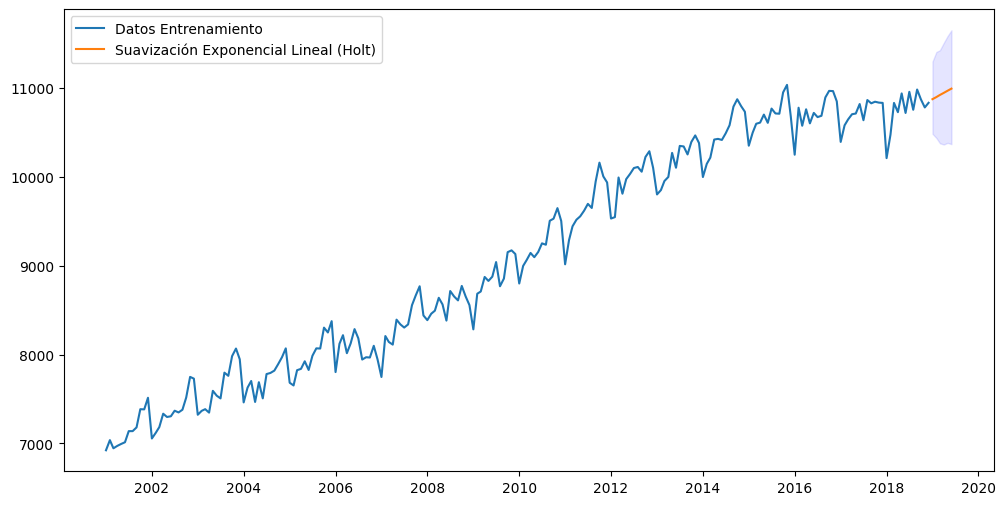

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos Entrenamiento")
plt.plot(preds_holt['Point_forecast'], label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt.index, preds_holt['lower_95'], preds_holt['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En este caso, el modelo de suavización exponencial lineal de Holt estima un α de 0.5506 y un β de 0.00005506. El valor de α indica que el modelo asigna un peso importante a las observaciones recientes de la serie **Ocupados** para actualizar el nivel. Sin embargo, el valor de β es muy cercano a cero, lo que sugiere que el componente de tendencia tiene un efecto muy bajo en la actualización del modelo. El RMSE obtenido en la muestra de evaluación es 317.49, calculado al comparar los pronósticos generados para los 6 meses de prueba frente a los valores reales observados. Al comparar este resultado con el modelo de suavización exponencial simple, cuyo RMSE fue 253.64, se observa que el modelo de Holt presenta un mayor error de pronóstico. Por tanto, hasta este punto, la incorporación de tendencia no mejora el desempeño predictivo de la serie **Ocupados**.

In [ ]:
alpha_holt = ets_result.alpha
beta_holt = ets_result.beta

print(f"Alpha estimado: {alpha_holt:.4f}")
print(f"Beta estimado: {beta_holt:.8f}")

Alpha estimado: 0.5506
Beta estimado: 0.00005506


In [ ]:
rmse_holt = np.sqrt(mean_squared_error(test_ocupados, preds_holt['Point_forecast']))
print(f"RMSE Holt: {rmse_holt:.2f}")

RMSE Holt: 317.49


### **3.3 Suavización Exponencial Lineal de Winters (Holt-Winters)**

En esta sección se ajustarán modelos de suavización exponencial de Holt-Winters para la serie **Ocupados**. A diferencia de los métodos anteriores, este enfoque permite incorporar no solo el nivel de la serie mediante el parámetro α y, en algunos casos, la tendencia mediante β, sino también un componente estacional mediante γ. Esto es importante porque la ocupación puede presentar patrones que se repiten en ciertos meses del año, asociados a dinámicas económicas, comerciales o laborales propias del mercado. Por esta razón, se evaluarán especificaciones que incluyan estacionalidad aditiva o multiplicativa, con el propósito de identificar si la incorporación de patrones estacionales mejora la capacidad predictiva del modelo frente a la suavización exponencial simple y al modelo de Holt. Al igual que en los casos anteriores, el desempeño se evaluará mediante el RMSE calculado sobre los 6 meses reservados como muestra de prueba.

In [ ]:
# Build model
ets_model = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend="add", seasonal="add")
ets_result = ets_model.fit()

point_forecast = ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05) #.iloc[:,0]
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10349.094194  10090.610132  10607.578256
2019-02-01    10624.690071  10350.551423  10898.828720
2019-03-01    10770.101783  10481.152558  11059.051007
2019-04-01    10786.274106  10483.234541  11089.313670
2019-05-01    10870.829275  10554.323400  11187.335150
2019-06-01    10828.784921  10499.360228  11158.209614


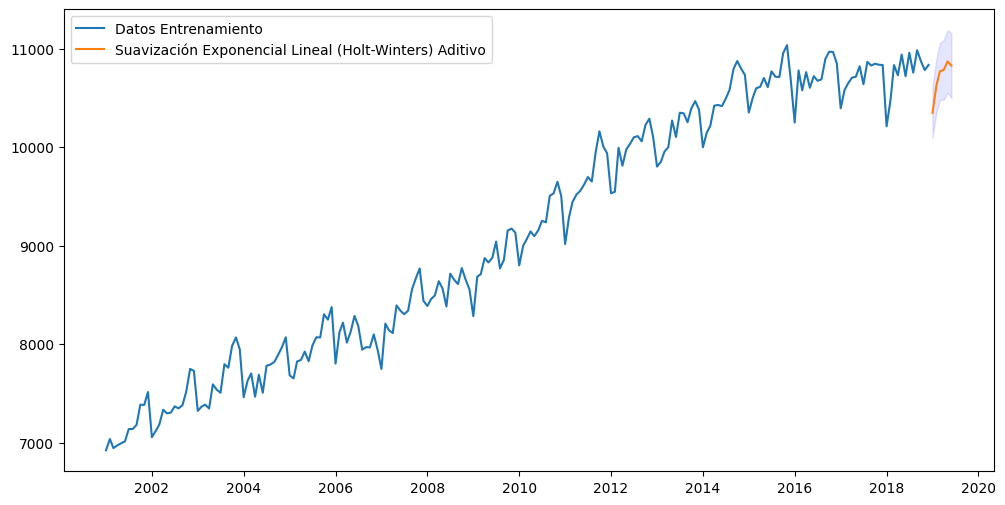

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'], label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.fill_between(preds_hw_add.index, preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En este caso, el modelo Holt-Winters aditivo estima un α de 0.3532, un β de 0.00003532 y un γ de 0.2969. El parámetro α indica que el modelo asigna un peso moderado a las observaciones recientes para actualizar el nivel de la serie **Ocupados**. El valor de β es muy cercano a cero, lo que sugiere que la actualización de la tendencia es baja dentro del modelo. Por su parte, γ refleja la incorporación del componente estacional, lo cual permite capturar patrones que pueden repetirse en ciertos meses del año. El RMSE obtenido en la muestra de evaluación es 74.44, valor considerablemente menor que los obtenidos con la suavización exponencial simple y con el modelo de Holt. Esto sugiere que, hasta este punto del análisis, la incorporación de estacionalidad aditiva mejora de manera importante el desempeño predictivo de la serie **Ocupados**.

In [ ]:
alpha_hw_add = ets_result.alpha
beta_hw_add = ets_result.beta
gamma_hw_add = ets_result.gamma

print(f"Alpha estimado: {alpha_hw_add:.4f}")
print(f"Beta estimado: {beta_hw_add:.8f}")
print(f"Gamma estimado: {gamma_hw_add:.8f}")

Alpha estimado: 0.3532
Beta estimado: 0.00003532
Gamma estimado: 0.29694595


In [ ]:
rmse_hw_add = np.sqrt(mean_squared_error(test_ocupados, preds_hw_add['Point_forecast']))
print(f"RMSE Holt-Winters Aditivo: {rmse_hw_add:.2f}")

RMSE Holt-Winters Aditivo: 74.44


In [ ]:
# Build model.
ets_model = ETSModel(endog=train_ocupados["Ocupados"], error="add", trend=None, seasonal="mul")
ets_result = ets_model.fit()

point_forecast = ets_result.forecast(6)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05) #.iloc[:,0]
limits = ci.predicted_mean


preds_hw_mul = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10325.781740  10105.045603  10558.181940
2019-02-01    10527.749200  10263.667454  10803.439776
2019-03-01    10611.310498  10331.661322  10904.299224
2019-04-01    10620.935091  10299.302398  10967.271823
2019-05-01    10689.617917  10337.348709  11026.616501
2019-06-01    10645.660972  10254.507171  11051.626919


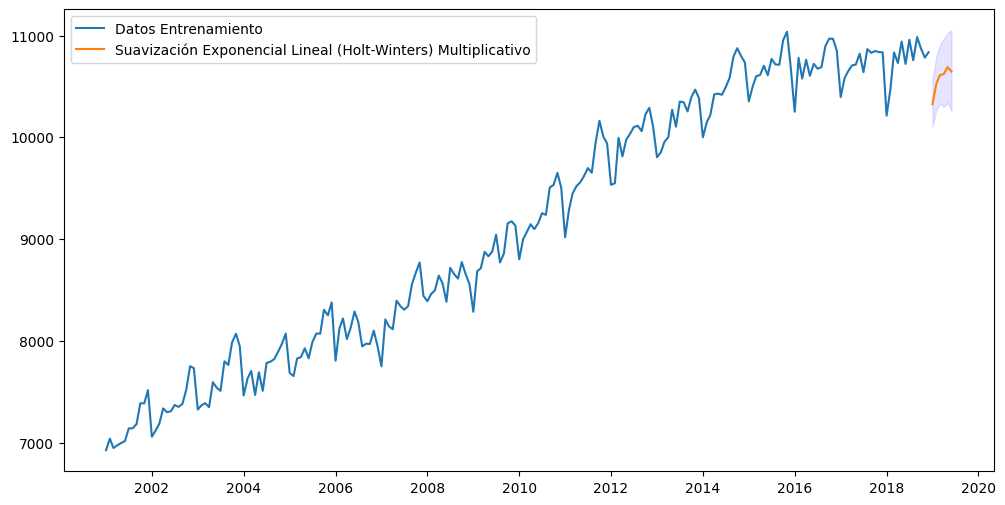

In [ ]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_ocupados, label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'], label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.fill_between(preds_hw_mul.index, preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

En este caso, el modelo Holt-Winters multiplicativo estima un α de 0.5975 y un γ de 0.00004025. El valor de α indica que el modelo asigna un peso importante a las observaciones recientes para actualizar el nivel de la serie **Ocupados**. Por su parte, el valor de γ es muy cercano a cero, lo que sugiere que el componente estacional multiplicativo tiene una actualización muy baja dentro del modelo. El RMSE obtenido en la muestra de evaluación es 115.23, calculado al comparar los pronósticos generados para los 6 meses de prueba frente a los valores reales observados. Este resultado mejora frente a la suavización exponencial simple y frente al modelo de Holt, pero no supera al modelo Holt-Winters aditivo, cuyo RMSE fue 74.44. Por tanto, hasta este punto, el modelo Holt-Winters aditivo continúa mostrando el mejor desempeño predictivo para la serie **Ocupados**.

In [ ]:
alpha_hw_mul = ets_result.alpha
gamma_hw_mul = ets_result.gamma

print(f"Alpha estimado: {alpha_hw_mul:.4f}")
print(f"Gamma estimado: {gamma_hw_mul:.8f}")

Alpha estimado: 0.5975
Gamma estimado: 0.00004025


In [ ]:
rmse_hw_mul = np.sqrt(mean_squared_error(test_ocupados, preds_hw_mul['Point_forecast']))
print(f"RMSE Holt-Winters Multiplicativo: {rmse_hw_mul:.2f}")

RMSE Holt-Winters Multiplicativo: 115.23


# **3.4 Selección del mejor modelo**

In [ ]:
from itertools import product
import warnings

warnings.filterwarnings("ignore")

# Opciones posibles para cada componente del modelo ETS
opciones_error = ["add", "mul"]
opciones_trend = [None, "add", "mul"]
opciones_seasonal = [None, "add", "mul"]

resultados_modelos = []

contador = 1

for error, trend, seasonal in product(opciones_error, opciones_trend, opciones_seasonal):

    nombre_modelo = f"Modelo {contador}"

    try:
        # Construcción del modelo
        ets_model = ETSModel(
            endog=train_ocupados["Ocupados"],
            error=error,
            trend=trend,
            seasonal=seasonal
        )

        # Ajuste del modelo
        ets_result_temp = ets_model.fit()

        # Pronóstico para los 6 meses de prueba
        point_forecast_temp = ets_result_temp.forecast(6)

        # Cálculo del RMSE
        rmse_temp = np.sqrt(
            mean_squared_error(test_ocupados, point_forecast_temp)
        )

        # Extracción de parámetros
        alpha_temp = ets_result_temp.alpha
        beta_temp = ets_result_temp.beta if trend is not None else np.nan
        gamma_temp = ets_result_temp.gamma if seasonal is not None else np.nan

        resultados_modelos.append({
            "Modelo": nombre_modelo,
            "error": error,
            "trend": trend,
            "seasonal": seasonal,
            "alfa": alpha_temp,
            "beta": beta_temp,
            "gamma": gamma_temp,
            "RMSE": rmse_temp
        })

    except Exception as e:
        resultados_modelos.append({
            "Modelo": nombre_modelo,
            "error": error,
            "trend": trend,
            "seasonal": seasonal,
            "alfa": np.nan,
            "beta": np.nan,
            "gamma": np.nan,
            "RMSE": np.nan
        })

    contador += 1


# Construcción de la tabla resumen
tabla_modelos_ets = pd.DataFrame(resultados_modelos)

# Identificación del mejor modelo según menor RMSE
indice_mejor_modelo = tabla_modelos_ets["RMSE"].idxmin()

tabla_modelos_ets.loc[indice_mejor_modelo, "Modelo"] = (
    "*** " + tabla_modelos_ets.loc[indice_mejor_modelo, "Modelo"] + " ***"
)

# Redondeo para presentación
tabla_modelos_ets["alfa"] = tabla_modelos_ets["alfa"].round(4)
tabla_modelos_ets["beta"] = tabla_modelos_ets["beta"].round(8)
tabla_modelos_ets["gamma"] = tabla_modelos_ets["gamma"].round(8)
tabla_modelos_ets["RMSE"] = tabla_modelos_ets["RMSE"].round(2)

tabla_modelos_ets

,Modelo,error,trend,seasonal,alfa,beta,gamma,RMSE
0,Modelo 1,add,None,None,0.6337,NaN,NaN,253.64
1,Modelo 2,add,None,add,0.5666,NaN,0.135119,83.95
2,Modelo 3,add,None,mul,0.5975,NaN,0.000040,115.23
3,Modelo 4,add,add,None,0.5726,0.006405,NaN,296.16
4,Modelo 5,add,add,add,0.3532,0.000035,0.296946,74.44
5,Modelo 6,add,add,mul,0.5243,0.001805,0.000048,59.63
6,Modelo 7,add,mul,None,0.5483,0.000055,NaN,307.50
7,Modelo 8,add,mul,add,0.4076,0.000041,0.334127,66.50
8,*** Modelo 9 ***,add,mul,mul,0.5254,0.000053,0.000047,59.42
9,Modelo 10,mul,None,None,0.6340,NaN,NaN,253.63


Con el propósito de realizar una selección más robusta del modelo de pronóstico, se evaluaron las 18 combinaciones posibles de los componentes ETS, considerando error aditivo o multiplicativo, tendencia ausente, aditiva o multiplicativa, y estacionalidad ausente, aditiva o multiplicativa. Para cada especificación se estimaron los parámetros α, β y γ cuando aplicaban, y posteriormente se calculó el RMSE sobre los 6 meses reservados como muestra de evaluación. Los resultados muestran que los modelos que incorporan estacionalidad presentan, en general, un mejor desempeño que aquellos basados únicamente en nivel o tendencia. En particular, el menor RMSE se obtuvo con el **Modelo 9**, especificado con error aditivo, tendencia multiplicativa y estacionalidad multiplicativa, con un RMSE de **59.42**. Este resultado supera ligeramente al Modelo 6, que obtuvo un RMSE de 59.63, y mejora de forma considerable frente a los modelos más simples. Por tanto, dentro de las combinaciones evaluadas, el Modelo 9 se selecciona como la mejor alternativa para pronosticar la serie **Ocupados**, al presentar el menor error fuera de muestra.

# **3.4.1 Construcción del mejor modelo**

A partir de la comparación de las 18 combinaciones posibles de modelos ETS, se seleccionó como mejor alternativa el **Modelo 9**, especificado con error aditivo, tendencia multiplicativa y estacionalidad multiplicativa. Este modelo obtuvo el menor RMSE en la muestra de evaluación, con un valor de **59.42**, lo que indica que presentó el mejor desempeño predictivo para los 6 meses reservados como prueba. La comparación entre los valores reales y los pronosticados muestra que el modelo logra capturar de forma adecuada el comportamiento reciente de la serie **Ocupados**, incorporando tanto el nivel de la serie como su tendencia y patrón estacional. Por esta razón, este modelo será utilizado posteriormente para realizar el pronóstico final con toda la información disponible.

In [ ]:
# Mejor modelo seleccionado: Modelo 9
# Especificación: error aditivo, tendencia multiplicativa y estacionalidad multiplicativa

mejor_modelo = ETSModel(
    endog=train_ocupados["Ocupados"],
    error="add",
    trend="mul",
    seasonal="mul"
)

mejor_resultado = mejor_modelo.fit()

pronostico_mejor_modelo = mejor_resultado.forecast(6)

ci_mejor = mejor_resultado.get_prediction(
    start=pronostico_mejor_modelo.index[0],
    end=pronostico_mejor_modelo.index[-1]
)

conf_mejor = ci_mejor.pred_int(alpha=0.05)
limits_mejor = ci_mejor.predicted_mean

preds_mejor_modelo = pd.concat([limits_mejor, conf_mejor], axis=1)
preds_mejor_modelo.columns = ["Point_forecast", "lower_95", "upper_95"]

preds_mejor_modelo

,Point_forecast,lower_95,upper_95
2019-01-01,10367.442166,10145.373916,10572.570069
2019-02-01,10585.346764,10329.145369,10846.371264
2019-03-01,10687.324428,10403.910552,10955.133922
2019-04-01,10715.038053,10408.052510,11040.002172
2019-05-01,10802.109635,10477.423937,11128.076523
2019-06-01,10775.743722,10425.145883,11149.193022


In [ ]:
alpha_mejor = mejor_resultado.alpha
beta_mejor = mejor_resultado.beta
gamma_mejor = mejor_resultado.gamma

rmse_mejor = np.sqrt(
    mean_squared_error(test_ocupados, preds_mejor_modelo["Point_forecast"])
)

print(f"Mejor modelo: Modelo 9")
print(f"Error: add")
print(f"Trend: mul")
print(f"Seasonal: mul")
print(f"Alpha estimado: {alpha_mejor:.4f}")
print(f"Beta estimado: {beta_mejor:.8f}")
print(f"Gamma estimado: {gamma_mejor:.8f}")
print(f"RMSE: {rmse_mejor:.2f}")

Mejor modelo: Modelo 9
Error: add
Trend: mul
Seasonal: mul
Alpha estimado: 0.5254
Beta estimado: 0.00005254
Gamma estimado: 0.00004746
RMSE: 59.42


In [ ]:
comparacion_mejor_modelo = pd.DataFrame({
    "Ocupados reales": test_ocupados["Ocupados"],
    "Pronóstico": preds_mejor_modelo["Point_forecast"],
    "Límite inferior 95%": preds_mejor_modelo["lower_95"],
    "Límite superior 95%": preds_mejor_modelo["upper_95"]
})

comparacion_mejor_modelo["Error"] = (
    comparacion_mejor_modelo["Ocupados reales"] -
    comparacion_mejor_modelo["Pronóstico"]
)

comparacion_mejor_modelo.round(2)

,Ocupados reales,Pronóstico,Límite inferior 95%,Límite superior 95%,Error
2019-01-01,10314.44,10367.44,10145.37,10572.57,-53.00
2019-02-01,10557.92,10585.35,10329.15,10846.37,-27.43
2019-03-01,10760.78,10687.32,10403.91,10955.13,73.45
2019-04-01,10632.03,10715.04,10408.05,11040.00,-83.01
2019-05-01,10813.00,10802.11,10477.42,11128.08,10.89
2019-06-01,10848.00,10775.74,10425.15,11149.19,72.26


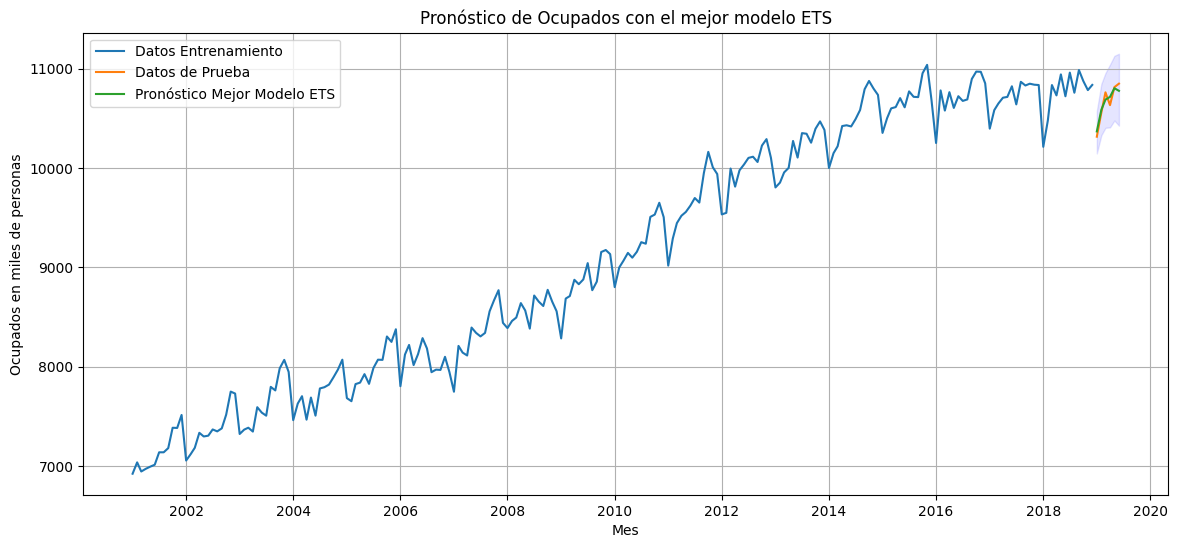

In [ ]:
fig = plt.figure(figsize=(14, 6))

plt.plot(train_ocupados, label="Datos Entrenamiento")
plt.plot(test_ocupados, label="Datos de Prueba")
plt.plot(
    preds_mejor_modelo["Point_forecast"],
    label="Pronóstico Mejor Modelo ETS"
)

plt.fill_between(
    preds_mejor_modelo.index,
    preds_mejor_modelo["lower_95"],
    preds_mejor_modelo["upper_95"],
    color="blue",
    alpha=0.1
)

plt.title("Pronóstico de Ocupados con el mejor modelo ETS")
plt.xlabel("Mes")
plt.ylabel("Ocupados en miles de personas")

plt.legend()
plt.grid(True)
plt.show()

## **4. Pronosticando con todo el dataset**

Una vez evaluadas las diferentes especificaciones del modelo ETS sobre la muestra de entrenamiento y prueba, se seleccionó como mejor alternativa el modelo con **error aditivo, tendencia multiplicativa y estacionalidad multiplicativa**, debido a que presentó el menor RMSE en la muestra de evaluación. A partir de esta selección, el siguiente paso consiste en ajustar nuevamente dicho modelo, pero ahora utilizando **toda la información disponible** de la serie **Ocupados**. Esta decisión permite aprovechar la totalidad de los datos históricos antes de generar el pronóstico final para los próximos 6 meses. En esta etapa ya no se separan datos de entrenamiento y prueba, porque el objetivo no es evaluar el modelo, sino producir las proyecciones finales con base en el mejor modelo identificado previamente.

In [ ]:
# Ajuste del modelo final con toda la serie disponible de Ocupados
# Mejor modelo seleccionado: error aditivo, tendencia multiplicativa y estacionalidad multiplicativa

final_model = ETSModel(
    endog=data["Ocupados"],
    error="add",
    trend="mul",
    seasonal="mul"
)

final_model_fit = final_model.fit_constrained({
    'smoothing_level': alpha_mejor,
    'smoothing_trend': beta_mejor,
    'smoothing_seasonal': gamma_mejor
})

print("Modelo final seleccionado para la serie Ocupados")
print("------------------------------------------------")
print("Error: add")
print("Trend: mul")
print("Seasonal: mul")
print("")
print(f"Alpha estimado utilizado: {final_model_fit.alpha:.4f}")
print(f"Beta estimado utilizado: {final_model_fit.beta:.8f}")
print(f"Gamma estimado utilizado: {final_model_fit.gamma:.8f}")

Modelo final seleccionado para la serie Ocupados
------------------------------------------------
Error: add
Trend: mul
Seasonal: mul

Alpha estimado utilizado: 0.5254
Beta estimado utilizado: 0.00005254
Gamma estimado utilizado: 0.00004746


In [ ]:
point_forecast = final_model_fit.forecast(6)

ci = final_model_fit.get_prediction(start = point_forecast.index[0],
                                    end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05) #.iloc[:,0]
limits = ci.predicted_mean


preds_final = pd.concat([limits, conf_forecast], axis = 1)
preds_final.columns = ['Pronóstico puntual', 'Límite inferior 95%', 'Límite superior 95%']

print("Pronóstico final de Ocupados para los próximos 6 meses")
print("------------------------------------------------------")
display(preds_final.round(2))

Pronóstico final de Ocupados para los próximos 6 meses
------------------------------------------------------


,Pronóstico puntual,Límite inferior 95%,Límite superior 95%
2019-07-01,10915.69,10700.14,11132.66
2019-08-01,10904.07,10653.48,11162.47
2019-09-01,10997.72,10730.24,11276.37
2019-10-01,11140.58,10848.25,11445.12
2019-11-01,11165.79,10850.93,11505.60
2019-12-01,11070.07,10738.79,11425.62


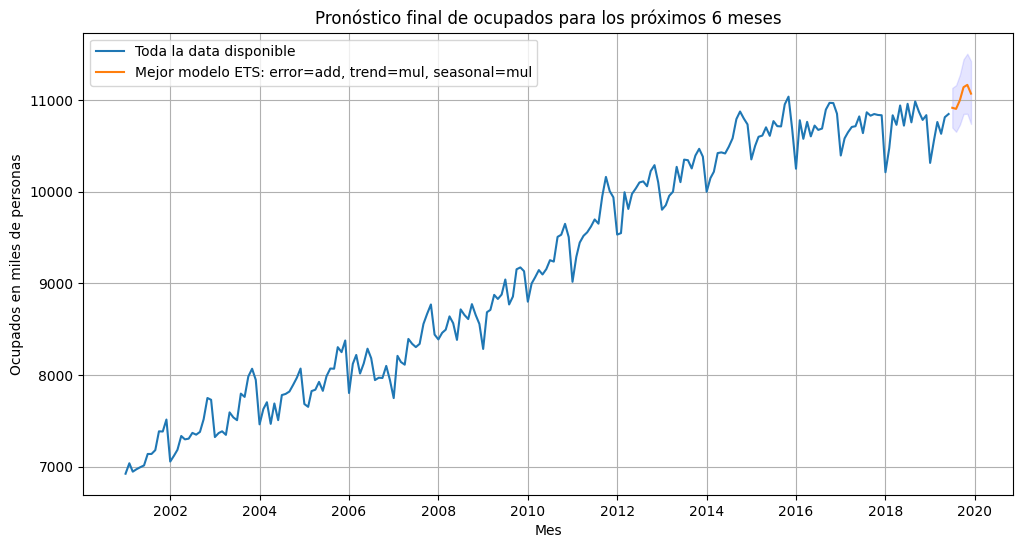

In [ ]:
fig = plt.figure(figsize=(12, 6))

plt.plot(data["Ocupados"], label="Toda la data disponible")
plt.plot(
    preds_final["Pronóstico puntual"],
    label="Mejor modelo ETS: error=add, trend=mul, seasonal=mul"
)

plt.fill_between(
    preds_final.index,
    preds_final["Límite inferior 95%"],
    preds_final["Límite superior 95%"],
    color="blue",
    alpha=0.1
)

plt.title("Pronóstico final de ocupados para los próximos 6 meses")
plt.xlabel("Mes")
plt.ylabel("Ocupados en miles de personas")

plt.legend()
plt.grid(True)
plt.show()

## **5. Ejercicio en Clase**

Empleando la información del número de ocupados en miles de personas (Ocupados) para las 13 principales ciudades, encuentre el mejor pronóstico para los próximos 6 meses. Escriba un breve informe de máximo una página de texto que explique cómo llega a sus proyeccciones y presente las proyecciones. Aclare en el texto cuáles serían las limitaciones de sus pronósticos.